# Lab 9 -- Random Forest Classifer

#### Author: Esraaj Sarkar Gupta
#### Date: 22nd March 2026

<All I want is a little more than Ill ever get>

In [17]:
# ---- Imports ---- #
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("Imports completed....")

Imports completed....


In [18]:
# ---- Downloads ---- #
nltk.download('punkt')
nltk.download('stopwords')

# ---- Seeding ---- #
np.random.seed(0)   # I would've preferred a different number but this is fine too

# ---- Load Data ---- #
df = pd.read_csv('factoryReports.csv')

display(df.head())

[nltk_data] Downloading package punkt to /home/esraaj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/esraaj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Description,Category,Urgency,Resolution,Cost
0,Items are occasionally getting stuck in the sc...,Mechanical Failure,Medium,Readjust Machine,45
1,Loud rattling and banging sounds are coming fr...,Mechanical Failure,Medium,Readjust Machine,35
2,There are cuts to the power when starting the ...,Electronic Failure,High,Full Replacement,16200
3,Fried capacitors in the assembler.,Electronic Failure,High,Replace Components,352
4,Mixer tripped the fuses.,Electronic Failure,Low,Add to Watch List,55


In [19]:
# Define the English stop words
stop_words = set(
    stopwords.words('english')
    )

def preprocess_text(text):
    """
    Preprocess text:
    - All text is converted to lowercase
    - All words are tokenized
    - Stopwords and non-alphabetic characters are removed
    """
    # Convert text to lower case
    text = str(text).lower()
    
    # Tokenize the individual words
    tokens = word_tokenize(text)
    
    # Remove noise -- non-alphabetic characters and English stopwords
    clean_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    
    # Join the tokens back into a single string
    return " ".join(clean_tokens)

# Apply the preprocessing function to the relevant columns
df['Description']   = df['Description'].apply(preprocess_text)
df['Category']      = df['Category'].apply(preprocess_text)

# What have we here?
print(df[['Description', 'Category']].head())

                                         Description            Category
0    items occasionally getting stuck scanner spools  mechanical failure
1  loud rattling banging sounds coming assembler ...  mechanical failure
2                          cuts power starting plant  electronic failure
3                         fried capacitors assembler  electronic failure
4                                mixer tripped fuses  electronic failure


In [ ]:
# ---- Apply TF-IDF vectorizer ---- #

# Init TF-IDF
tfidf = TfidfVectorizer()

# Fit and transform preprocessed text
X = tfidf.fit_transform(df['Description'])
y = df['Category']

# ---- Train-Test Splits ---- #
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67) # No seed specified, I dutifully choose.

In [31]:
# ---- Train and Fit ----- #
# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # Why can't we have better numbers?

# Fit model on training data
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# ---- Prediction ---- #

y_pred = rf_classifier.predict(X_test)

Model Accuracy: 90.62%



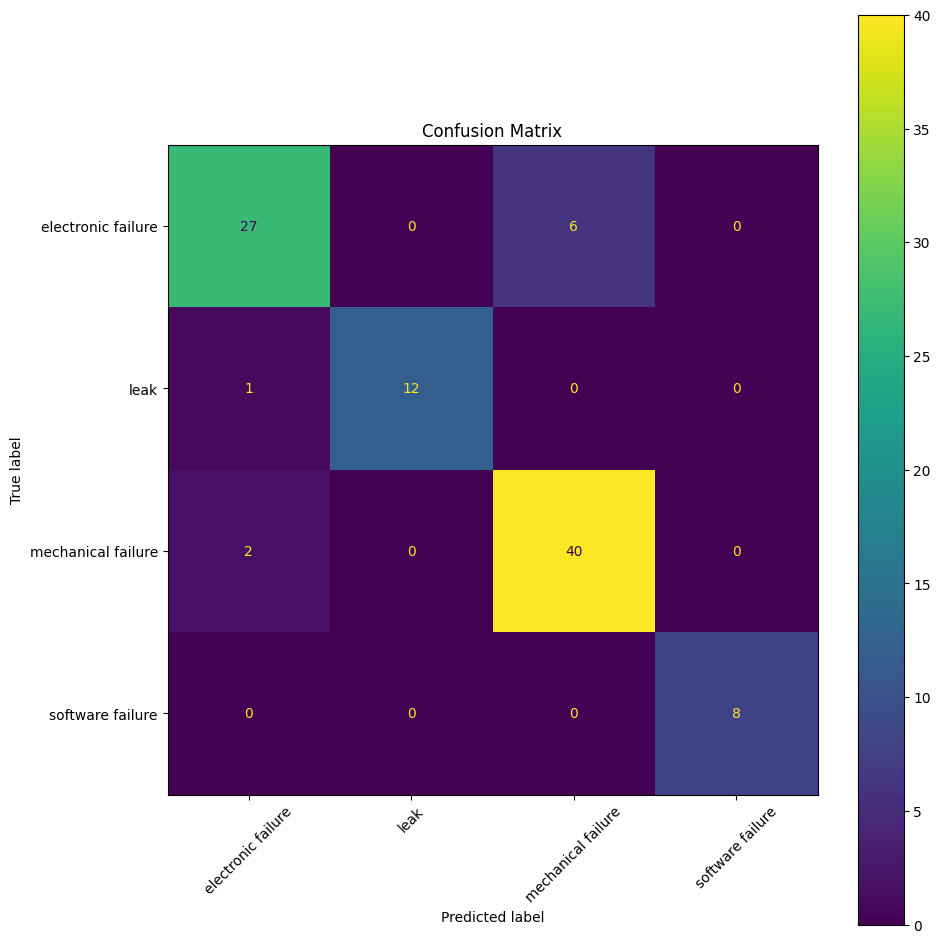

In [30]:
# ---- Performance Metrics ---- #

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_classifier.classes_)

# Plotting and all that
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_classifier.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='viridis', xticks_rotation=45) # How pretty.
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Report

<Who do I report to>

#### Question 1
The primary techniques used for keyword normalization in NLP are stemming and lemmatization.
<br><br>
Stemming applies basic heuristic rules to truncate prefixed and suffixes of words to get the word root. On the other hand, lemmatization uses detailed vocabulary and morphological analysis to reduce a word to the proper dictionary form of a word.

#### Question 2

TF-IDF -- Term Frequency - Inverse Document Frequecy is a statistical measure used to evaluate the importance of a word within a document part of a larger corpus mathematically. This is done by highlighting words that appear frequently in a specific text but not across the entire dataset, ensuring that the unique keywords are preserved.

$$
TF(t, d) = \frac{\text{Count of term } t \text{ in document } d}{\text{Total number of words in document } d}
$$

$$
IDF(t, D) = \log \left( \frac{N}{df_t} \right)
$$

$$
\text{TF-IDF}(t, d, D) = TF(t, d) \times IDF(t, D)
$$

#### Question 3

Some TF-IDF alternatives are 
* BOW -- Bag of Words
* Word2Vec
* GloVe (Global Vectors for Word Representation)
* BERT (contextual embedding)

#### Question 4

The primary advantage of Word2Vec over TF-IDF is its ability to capture semantic meaning and contextual relationships between words. Word2Vec creates dense vectors that can capture relationships, whereas TF-IDF is reliant purely on word frequency.

#### Question 5

Some applications of the classification method implemented in this lab include
* automated routing of maintenance tickets to appropriate specialized support staff.
* clinical note processing -- unstructured clinical notes can be sorted through much faster based on brief search descriptions.